# 01 — EDA ventanas donor

Exploración de `donor_train` y `donor_validation` antes del entrenamiento WGAN-GP.

**Contrato:** ventanas `[65, 3]` con canales `log_return`, `log_high_low_range`, `log1p_volume`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import CHANNELS, load_donor_windows, windows_to_array
from src.metrics import channel_summary, temporal_autocorr_report
from src.paths import default_windows_dir

sns.set_theme(style="whitegrid")


I0000 00:00:1788434063.652158 1709059 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788434063.654169 1709059 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788434063.911508 1709059 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788434065.047393 1709059 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
windows_dir = default_windows_dir()
train = load_donor_windows("donor_train", windows_dir=windows_dir)
val = load_donor_windows("donor_validation", windows_dir=windows_dir)

X_train = windows_to_array(train)
X_val = windows_to_array(val)

print("train", X_train.shape, "validation", X_val.shape)
print("tickers train:", train["ticker"].nunique())
train.head()

train (4910, 65, 3) validation (380, 65, 3)
tickers train: 10


,split,ticker,window_start_date,window_end_date,features_flat
0,donor_train,ADI,2012-01-04,2012-04-05,"[-0.0013888800981320109, 0.011989556282318023,..."
1,donor_train,ADI,2012-01-11,2012-04-13,"[0.0040721172648543625, 0.01196312849561133, 1..."
2,donor_train,ADI,2012-01-19,2012-04-20,"[0.013194463040282529, 0.01725493984436187, 15..."
3,donor_train,ADI,2012-01-26,2012-04-27,"[-0.012648538196651363, 0.030678825570496573, ..."
4,donor_train,ADI,2012-02-02,2012-05-04,"[-0.00025364828075077, 0.013908410725421134, 1..."


In [3]:
display(channel_summary(X_train))
display(temporal_autocorr_report(X_train))

,channel,mean,std,min,max
0,log_return,0.000811,0.023516,-0.277456,0.420617
1,log_high_low_range,0.026026,0.016724,0.000000,0.273457
2,log1p_volume,16.060272,1.093325,0.000000,20.143947


,channel,autocorr_lag1_mean,autocorr_lag1_std
0,log_return,-0.042547,0.145960
1,log_high_low_range,0.252291,0.175862
2,log1p_volume,0.462904,0.143563


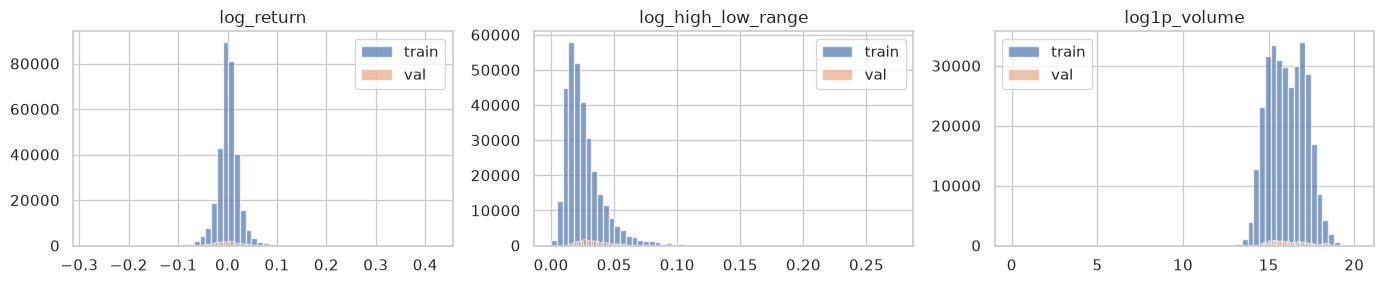

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, idx, name in zip(axes, range(3), CHANNELS):
    ax.hist(X_train[:, :, idx].reshape(-1), bins=60, alpha=0.7, label="train")
    ax.hist(X_val[:, :, idx].reshape(-1), bins=60, alpha=0.5, label="val")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_hist_train_val.png", dpi=140, bbox_inches="tight")


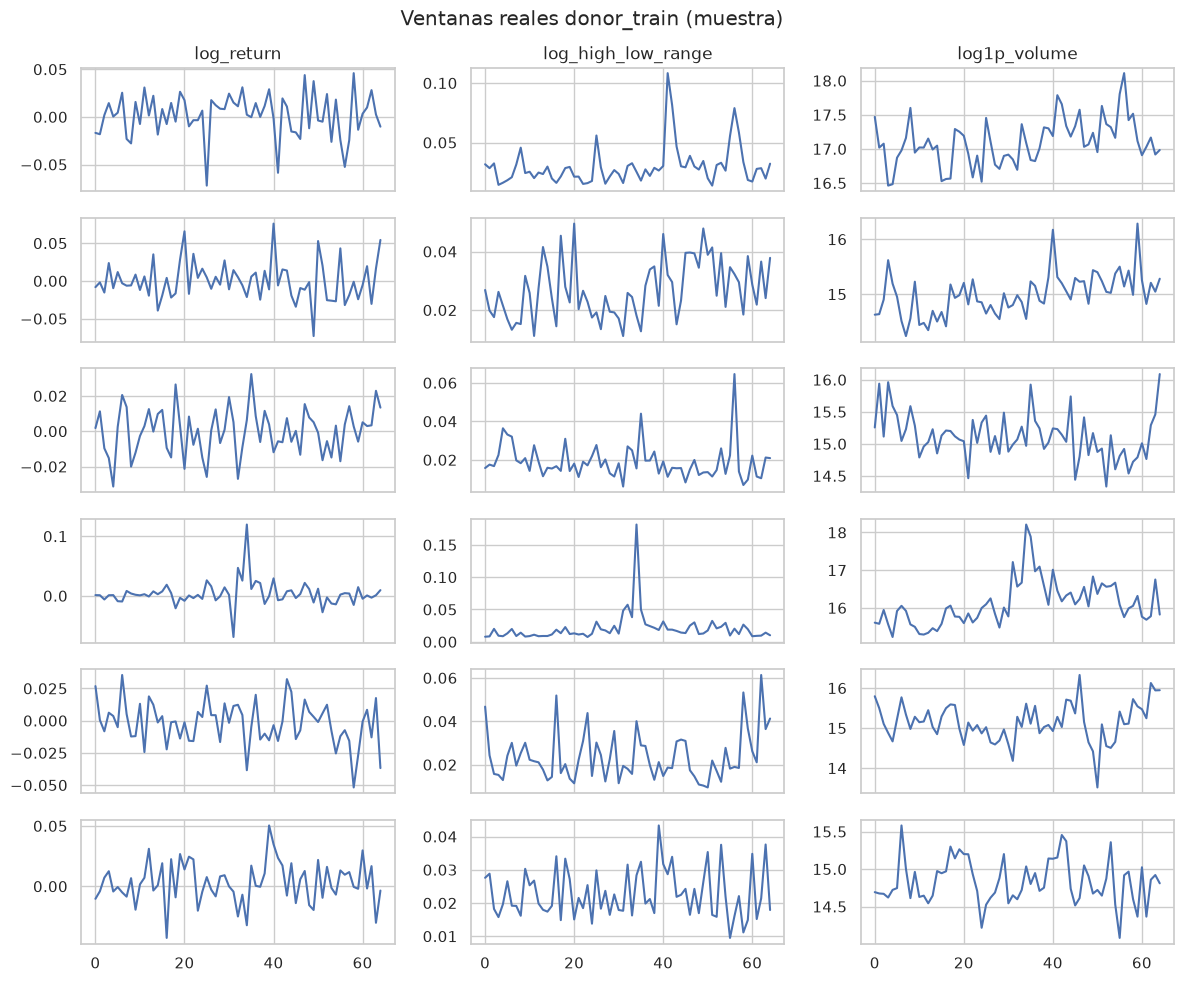

In [5]:
sample_idx = np.random.default_rng(42).choice(len(X_train), size=6, replace=False)
fig, axes = plt.subplots(6, 3, figsize=(12, 10), sharex=True)
for row, idx in enumerate(sample_idx):
    for col, name in enumerate(CHANNELS):
        axes[row, col].plot(X_train[idx, :, col])
        if row == 0:
            axes[row, col].set_title(name)
plt.suptitle("Ventanas reales donor_train (muestra)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_ventanas_donor_train.png", dpi=140, bbox_inches="tight")


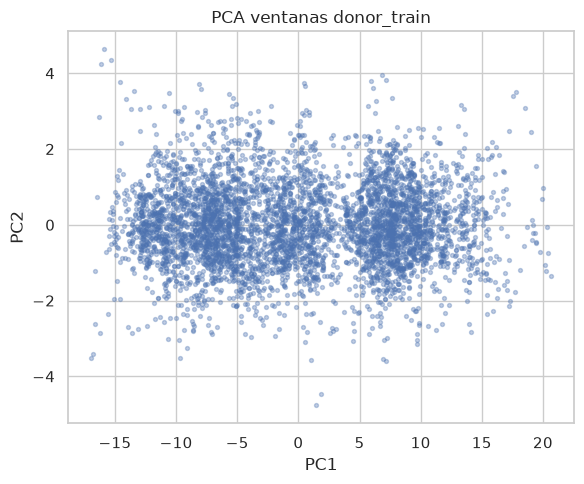

In [6]:
from sklearn.decomposition import PCA

flat = X_train.reshape(len(X_train), -1)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(flat)

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA ventanas donor_train")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_pca_donor_train.png", dpi=140, bbox_inches="tight")
